## 1、如何创建agent
通过调用langchain.agents.create_agent来构建一个agent，传入agent所能使用工具，以及agent的大脑：LLM

In [1]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch
import dotenv
from langgraph.checkpoint.memory import InMemorySaver

dotenv.load_dotenv()
llm = ChatOpenAI(
    model="gpt-4o-mini"
)
tavily_search_tool = TavilySearch(max_results=5)  # 返回的搜索结果的最大数量
tools = [tavily_search_tool]
agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt="你是一个智能助手，能够选择合适的工具帮助用户解决问题"
)
llm.invoke("你好")

AIMessage(content='你好！有什么我可以帮助你的吗？', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 8, 'total_tokens': 18, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_eb37e061ec', 'id': 'chatcmpl-DTQ6MGG5vhVSC7klaKYegKITb4S5K', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d7c23-cc31-7173-9337-b6190533f152-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 10, 'total_tokens': 18, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

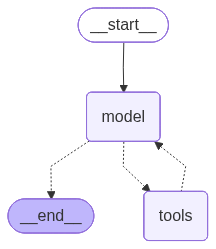

In [2]:
agent

In [3]:
print(type(agent))  # 类型为CompiledStateGraph: 带有状态的图

<class 'langgraph.graph.state.CompiledStateGraph'>


In [4]:
from langgraph.pregel._read import PregelNode

print(agent.input_schema)
from langchain_tavily import TavilySearch

type(agent.nodes['__start__'])

<class 'langgraph.graph.state.LangGraphInput'>


langgraph.pregel._read.PregelNode

In [5]:
agent.invoke({"key1": "你好"})

{'messages': [AIMessage(content='请告诉我您需要的帮助，我会为您找到合适的信息和工具。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 1200, 'total_tokens': 1220, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_eb37e061ec', 'id': 'chatcmpl-DTQ6OHUkSrO4NuR7eh4CcuEFOtTf8', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d7c23-e028-7de1-abb1-8d69e9bc9f2f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1200, 'output_tokens': 20, 'total_tokens': 1220, 'input_token_details': {'audio': 0, 'cache_read': 1152}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

## 2、使用agent

In [6]:
# 不能直接使用字符串来invoke，会报错，
agent.invoke("帮我查看下北京的天气怎么样")

InvalidUpdateError: Expected dict, got 帮我查看下北京的天气怎么样
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_GRAPH_NODE_RETURN_VALUE

In [7]:
# 调用需要通过messages key和消息列表作为value来调用
res = agent.invoke({"messages": [{"role": "user", "content": "帮我看下北京天气怎么样"}]})

In [8]:
type(res)
print(res.keys())

dict_keys(['messages'])


In [9]:
for message in res["messages"]:
    print(message.__class__, message, end="\n\n\n\n")

<class 'langchain_core.messages.human.HumanMessage'> content='帮我看下北京天气怎么样' additional_kwargs={} response_metadata={} id='0cdb72c9-4ade-4dca-8497-b8aea58644fc'



<class 'langchain_core.messages.ai.AIMessage'> content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 1211, 'total_tokens': 1233, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_eb37e061ec', 'id': 'chatcmpl-DTQ6dIAcp4M3loDXO3EKgOJQzryW5', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019d7c24-1434-73e1-8c11-a4776f591d3e-0' tool_calls=[{'name': 'tavily_search', 'args': {'query': '北京天气', 'topic': 'general'}, 'id': 'call_73lbCaSxcTSZpk1BLXwMZr4a', 'type': 'tool_call'}] invalid_tool_calls=[] usage_

In [10]:
res["messages"][-1]

AIMessage(content='目前北京的天气情况如下：\n\n- **温度**：约 18.3°C\n- **风速**：西南风，微风\n- **天气**：今天白天多云，最高气温约 26°C，夜间最低气温约 18°C\n\n你可以查看以下链接以获取更详细的天气信息：\n1. [Yahoo天气](https://weather.yahoo.com/cn/beijing/beijing/)\n2. [英国气象局](https://weather.metoffice.gov.uk/forecast/wx4g092se)\n3. [中央气象台](https://www.nmc.cn/publish/forecast/ABJ/beijing.html)\n4. [中国天气网](https://www.weather.com.cn/weather/101010100.shtml)\n\n希望这些信息对你有帮助！', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 172, 'prompt_tokens': 2783, 'total_tokens': 2955, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_eb37e061ec', 'id': 'chatcmpl-DTQ6in1YqXf36oVjyIBR5KRtMscLZ', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d7c24-2ed9-72e3-8fd9-a51

## 3、使用langsmith来追踪调用链
1. 为什么使用langsmith: agent封装了整个调用工具的交互流程，不好看到调用agent整体和llm的交互有哪些，通过langsmith就可以清晰看到
2. 使用方式：在langsmith申请api_key，构造以下环境变量：
LANGSMITH_TRACING=true
LANGSMITH_API_KEY=
LANGSMITH_ENDPOINT=https://api.smith.langchain.com
LANGSMITH_PROJECT=agent_proj。构造好后，load环境变量，之后langchain底层就可以自动将每次调用记录到langsmith当中了

## 4、如何在agent当中引入记忆
1. 在创建agent时，传入checkpointer参数，在测试环境下，可以传入InMemorySaver()，生产环境下，使用数据来保存记忆。
2. 在invoke时，需要指定，将记忆保存到哪个“会话”当中，指定方式，传入config参数：{"configurable":{"thread_id":1}},thread_id真正指定了，将记忆存入哪个“会话当中”

In [11]:
from langgraph.checkpoint.memory import InMemorySaver

agent_with_memory = create_agent(
    model=llm,
    tools=tools,
    system_prompt="你是一个智能助手，能够选择合适的工具帮助用户解决问题",
    checkpointer=InMemorySaver()
)

In [12]:
agent_with_memory.invoke({"messages": [{"role": "user", "content": "帮我看下北京天气怎么样"}]},
                         config={"configurable": {"thread_id": 1}})

{'messages': [HumanMessage(content='帮我看下北京天气怎么样', additional_kwargs={}, response_metadata={}, id='c7842ab5-d6b3-499d-bce6-fee14b35ccf8'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1211, 'total_tokens': 1238, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_eb37e061ec', 'id': 'chatcmpl-DTQ7ZVGegLmKcBqEcEdVPChYKcHHT', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d7c24-f22e-74f2-b405-ec4c2d10017b-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': '北京天气', 'time_range': 'day', 'topic': 'general'}, 'id': 'call_EKqLSvfQ3VHRarwPn2sEpwKa', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1211, 

In [13]:
agent_with_memory.invoke({"messages": [{"role": "user", "content": "我刚才问你什么了"}]},
                         config={"configurable": {"thread_id": 1}})["messages"][-1]

AIMessage(content='你刚才询问了北京的天气情况。我为你提供了当前的天气信息，包括温度、风速和湿度等。如果你还有其他问题或者需要更多信息，请告诉我！', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 4167, 'total_tokens': 4211, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 4096}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_eb37e061ec', 'id': 'chatcmpl-DTQ7fk6EVps3z14Uee877wl0y14Gz', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d7c25-1208-7460-ba5f-e36a7268ea1a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 4167, 'output_tokens': 44, 'total_tokens': 4211, 'input_token_details': {'audio': 0, 'cache_read': 4096}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [14]:
# 对比原生llm，无法维护消息列表状态
llm.invoke("北京天气怎么样")
llm.invoke("我刚才问你什么了")

AIMessage(content='抱歉，我无法看到之前的对话内容。请问您想问什么？我很乐意提供帮助！', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 14, 'total_tokens': 40, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_eb37e061ec', 'id': 'chatcmpl-DTQ7iDK4r97ABGWQ0AYGSEFgOJaaT', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d7c25-1e0f-7fc3-99bd-2a0267eac4ff-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 26, 'total_tokens': 40, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [15]:
agent_with_memory.invoke({"messages": [{"role": "user", "content": "我刚才问你什么了"}]},
                         config={"configurable": {"thread_id": 1}})["messages"][-1]

AIMessage(content='你刚才问了“帮我看下北京天气怎么样”。如果你有其他问题或者需要更详细的信息，请告诉我！', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 4224, 'total_tokens': 4254, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 4096}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_eb37e061ec', 'id': 'chatcmpl-DTQ7j8kEAhZNdGKyABcII1h35vKul', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d7c25-221f-7a00-bba5-2e09b3de752c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 4224, 'output_tokens': 30, 'total_tokens': 4254, 'input_token_details': {'audio': 0, 'cache_read': 4096}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [16]:
type(agent_with_memory)

langgraph.graph.state.CompiledStateGraph